# vilip1 SAE: training curves + benchmark vs. Biohub's general SAE

Two things in this notebook:
1. **Training diagnostics** for our domain-specific SAE (layer 23, k=64, dictionary=4096, trained on vilip1_full20k + composite_hotspot, natural binders held out) -- loss/FVE/dead-feature curves over the real 50-epoch run, from `training_log.csv`.
2. **Benchmark**: our trained SAE vs. Biohub's official general-purpose ESMC-300M SAE (`biohub/ESMC-300M-sae-k64-codebook16384`, also layer 23, dictionary=16384), evaluated on the identical held-out residues -- from `benchmark_summary.csv` (produced by `sae/training/benchmark.py`, using Biohub's official `add_sae_models` encode path + their published decoder weights, verified against their real installed source code, not a guessed formula).

NOTE: this notebook lives at `sae/analysis/` -- two directories deep from the repo root, so data paths need `../../`, not `../`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRAINING_LOG_PATH = "../../vilip1_layer23_sae_outputs/checkpoints/run1/training_log.csv"
BENCHMARK_PATH = "../../vilip1_layer23_sae_outputs/benchmark_results/benchmark_summary.csv"
OUTPUT_DIR = "../../vilip1_layer23_sae_outputs/analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Training curves (our model, 50 epochs)

In [2]:
log = pd.read_csv(TRAINING_LOG_PATH)
print(f"{len(log)} epochs logged")
log.tail()

50 epochs logged


,epoch,train_mse,train_auxk_loss,val_fve_pooled,val_avg_l0_pooled,num_dead,val_fve_composite_hotspot,val_fve_vilip1_full20k,val_avg_l0_composite_hotspot,val_avg_l0_vilip1_full20k
45,45,0.074264,0.000093,0.941157,63.999985,0,0.971123,0.891820,63.999952,64.0
46,46,0.074218,0.000125,0.941171,63.999820,0,0.971127,0.891851,63.999444,64.0
47,47,0.074171,0.000093,0.941190,63.999614,0,0.971134,0.891888,63.998808,64.0
48,48,0.074131,0.000093,0.941213,63.999907,0,0.971163,0.891901,63.999714,64.0
49,49,0.074093,0.000093,0.941256,63.999979,0,0.971203,0.891951,63.999936,64.0


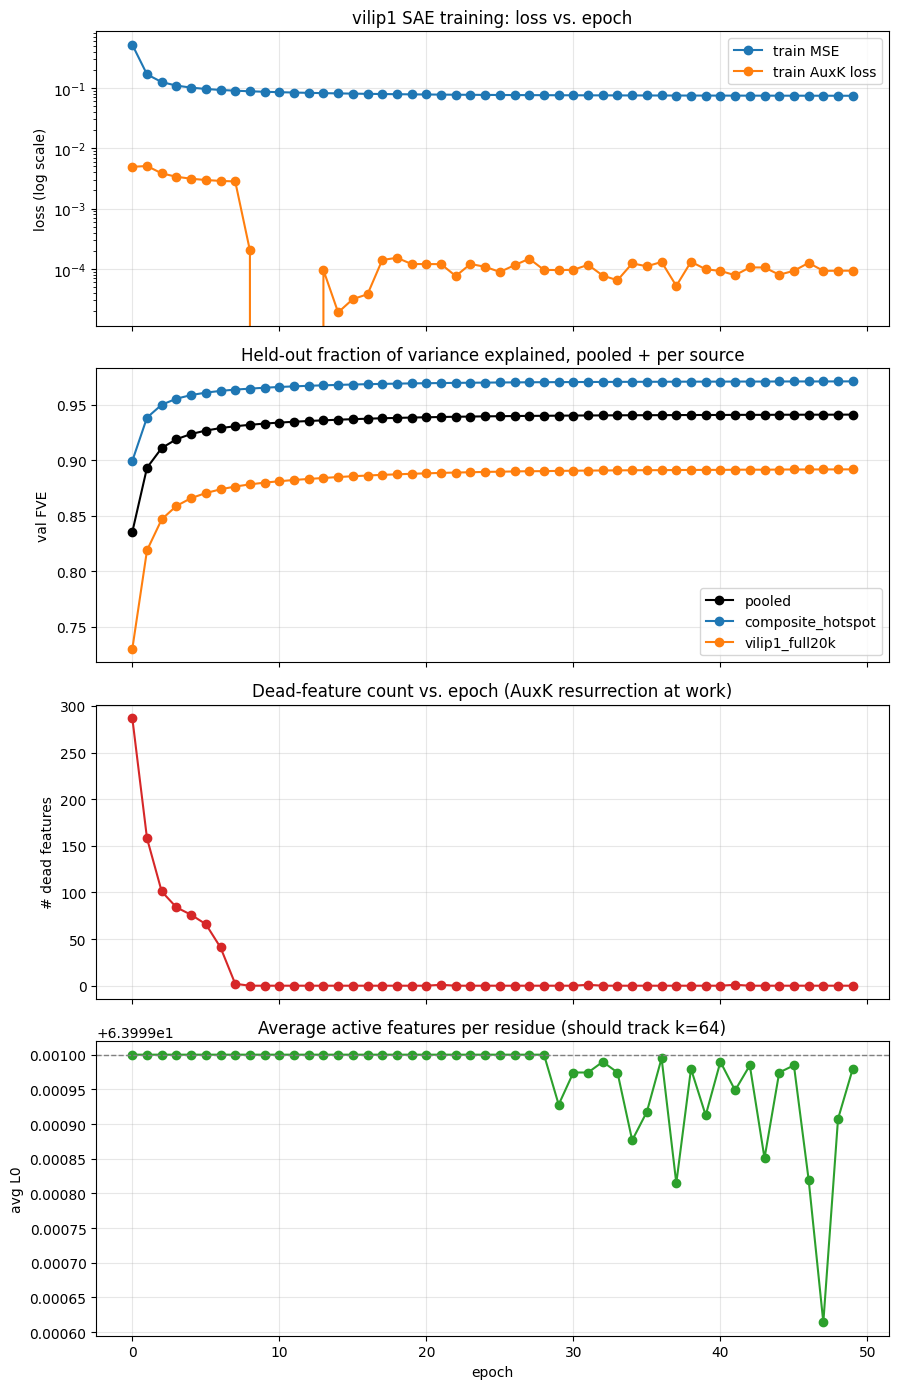

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(9, 14), sharex=True)

axes[0].plot(log["epoch"], log["train_mse"], marker="o", label="train MSE")
axes[0].plot(log["epoch"], log["train_auxk_loss"], marker="o", label="train AuxK loss")
axes[0].set_yscale("log")
axes[0].set_ylabel("loss (log scale)")
axes[0].set_title("vilip1 SAE training: loss vs. epoch")
axes[0].legend()

axes[1].plot(log["epoch"], log["val_fve_pooled"], marker="o", color="black", label="pooled")
axes[1].plot(log["epoch"], log["val_fve_composite_hotspot"], marker="o", label="composite_hotspot")
axes[1].plot(log["epoch"], log["val_fve_vilip1_full20k"], marker="o", label="vilip1_full20k")
axes[1].set_ylabel("val FVE")
axes[1].set_title("Held-out fraction of variance explained, pooled + per source")
axes[1].legend()

axes[2].plot(log["epoch"], log["num_dead"], marker="o", color="tab:red")
axes[2].set_ylabel("# dead features")
axes[2].set_title("Dead-feature count vs. epoch (AuxK resurrection at work)")

axes[3].plot(log["epoch"], log["val_avg_l0_pooled"], marker="o", color="tab:green")
axes[3].set_ylabel("avg L0")
axes[3].set_xlabel("epoch")
axes[3].set_title("Average active features per residue (should track k=64)")
axes[3].axhline(64, color="gray", linestyle="--", linewidth=1)

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=200)
plt.show()

In [4]:
print("Summary: epoch 0 -> epoch", log['epoch'].iloc[-1])
print(f"  train_mse: {log['train_mse'].iloc[0]:.4f} -> {log['train_mse'].iloc[-1]:.4f}")
print(f"  val_fve_pooled: {log['val_fve_pooled'].iloc[0]:.4f} -> {log['val_fve_pooled'].iloc[-1]:.4f}")
print(f"  num_dead: {log['num_dead'].iloc[0]:.0f} -> {log['num_dead'].iloc[-1]:.0f}")
print(f"  val_fve_composite_hotspot: {log['val_fve_composite_hotspot'].iloc[0]:.4f} -> {log['val_fve_composite_hotspot'].iloc[-1]:.4f}")
print(f"  val_fve_vilip1_full20k: {log['val_fve_vilip1_full20k'].iloc[0]:.4f} -> {log['val_fve_vilip1_full20k'].iloc[-1]:.4f}")

Summary: epoch 0 -> epoch 49
  train_mse: 0.5203 -> 0.0741
  val_fve_pooled: 0.8355 -> 0.9413
  num_dead: 287 -> 0
  val_fve_composite_hotspot: 0.8995 -> 0.9712
  val_fve_vilip1_full20k: 0.7301 -> 0.8920


## Benchmark: ours vs. Biohub's general SAE

Both evaluated on the exact same held-out residues (2500 held-out design proteins, stratified 90/10 split done in `data.py`, never seen during our training) plus the 13 natural-binder sequences (never used for anything except this qualitative pass). FVE computed against a shared baseline (our checkpoint's train-set mean, not a naive zero baseline -- see project notes on why raw-zero FVE is inflated by ESM-C's large outlier activation dimensions).

In [5]:
bench = pd.read_csv(BENCHMARK_PATH)
bench

,split,model,source,n_residues,fve,avg_l0,n_dead,dict_size
0,held_out_designs,ours,__pooled__,194341,0.941245,63.999969,1,4096
1,held_out_designs,ours,composite_hotspot,62922,0.971210,63.999905,1,4096
2,held_out_designs,ours,vilip1_full20k,131419,0.891930,64.000000,2,4096
3,held_out_designs,biohub,__pooled__,194341,0.715908,64.000000,1945,16384
4,held_out_designs,biohub,composite_hotspot,62922,0.692760,64.000000,3997,16384
5,held_out_designs,biohub,vilip1_full20k,131419,0.754005,64.000000,2873,16384
6,natural_binders_qualitative,ours,__pooled__,5362,0.419561,64.000000,29,4096
7,natural_binders_qualitative,ours,natural_binders,5362,0.419561,64.000000,29,4096
8,natural_binders_qualitative,biohub,__pooled__,5362,0.701551,64.000000,6522,16384
9,natural_binders_qualitative,biohub,natural_binders,5362,0.701551,64.000000,6522,16384


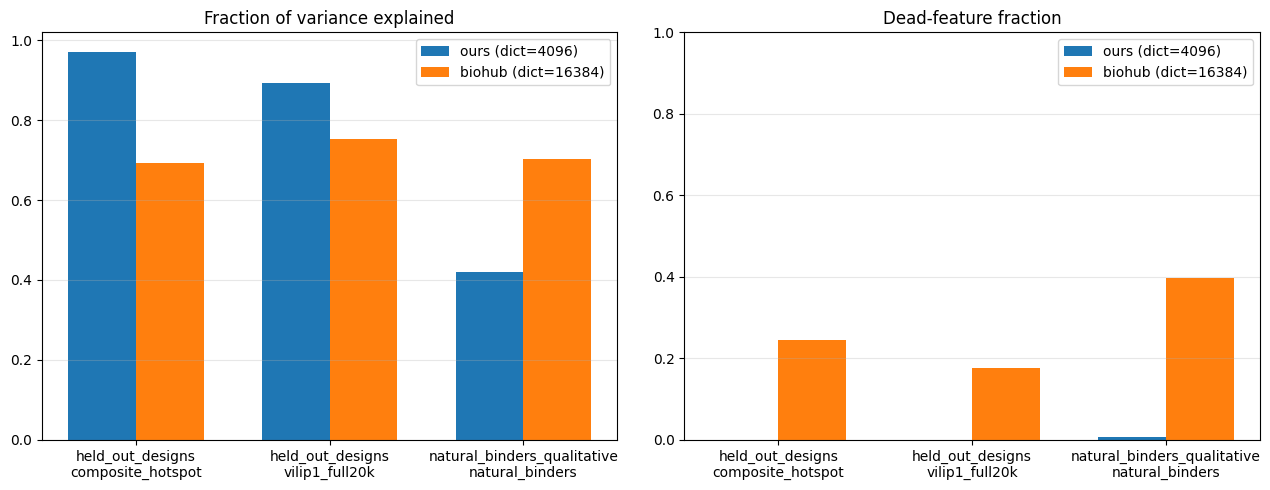

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_df = bench[bench["source"] != "__pooled__"].copy()
plot_df["group"] = plot_df["split"] + "\n" + plot_df["source"]

groups = sorted(plot_df["group"].unique())
x = np.arange(len(groups))
width = 0.35

for ax, metric, title in [
    (axes[0], "fve", "Fraction of variance explained"),
    (axes[1], None, "Dead-feature fraction"),
]:
    for i, model in enumerate(["ours", "biohub"]):
        sub = plot_df[plot_df["model"] == model].set_index("group").reindex(groups)
        if metric == "fve":
            values = sub["fve"]
        else:
            values = sub["n_dead"] / sub["dict_size"]
        ax.bar(x + i * width, values, width, label=f"{model} (dict={sub['dict_size'].iloc[0]})")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(groups, rotation=0)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")

axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/benchmark_comparison.png", dpi=200)
plt.show()

## Takeaways

- **On the actual design domain** (held_out_designs, 194,341 residues never seen in training): our domain-specific SAE clearly outperforms Biohub's general SAE (FVE 0.94 vs. 0.72) and uses its much smaller dictionary far more completely (near-zero dead features vs. ~12% dead for Biohub's).
- **On real, out-of-domain proteins** (natural_binders, 13 UniProt sequences never used in training at all): the result flips -- Biohub's general SAE generalizes much better (FVE 0.70 vs. 0.42) since it was trained broadly on UniRef90, while ours only ever saw synthetic Boltz-designed vilip1 binders.
- This is the expected specialist-vs-generalist trade-off, now measured directly rather than assumed.
- Per-source split is worth watching: composite_hotspot is *easier* for our model but *harder* for Biohub's, relative to vilip1_full20k -- not yet explained, just noted.
- **Not yet done**: a downstream-utility linear probe (do either model's sparse codes predict binding_confidence/iptm/ipsae/ipae, or agree with the HDBSCAN cluster labels from the earlier clustering notebooks?) -- ties reconstruction quality back to something biologically meaningful, planned as a follow-up, not computed here.